# Indice Synthétique de Convergence Technologique — v3

## Journal des versions

### v1 → problèmes identifiés
- **C2 domine entièrement la PCA** : loading = +1.0000, les 3 autres quasi nuls
- **Corrélations parasites** : paires rares avec C2 > 0.997 sans sens économique
- **Composantes orthogonales** (corr < 0.10) : la PCA n'est pas adaptée
- **Échec de validation** : indice déjà à 0.9 en 1980 avant toute convergence
- **Indice plat à 0.5** sur toute la période (signature de C2 aléatoire)

### v2 → corrections et problèmes résiduels
- ✅ Filtre n_cooc >= 20 : panel réduit de 1.38M à 184k lignes, paires parasites éliminées
- ✅ Log-transform sur C1 : insuffisant (log(1+x) ≈ x pour x << 1)
- ✅ Filtre C2 si n_cooc < 50 : 85.5% des C2 mis à 0, mais C2 domine encore
- ✅ Abandon PCA → pondération explicite : mais std(C2)=0.35 vs std(C1)=0.06
  → un poids 0.40/0.25 ne suffit pas à équilibrer des variances aussi déséquilibrées
- ❌ **Paires taxonomiques** : C10M×C10N (deux sous-classes pétrole) n°1 en 1990 et 2010
  → relation structurelle dans la classification CPC, pas une convergence innovante
- ❌ **Biais début de période** : indice décroissant (seules les paires très intenses
  passent le filtre en 1980, donnant des Jaccard artificiellement élevés)
- ❌ **C2 volatile** malgré le filtre (0.35 → 0.99 en un an pour A61P×C07D)
- ❌ **Chute artificielle après 2022** : fenêtre glissante incomplète en fin de période

### v3 → corrections apportées
1. **Filtre taxonomique** : exclusion des paires partageant les 3 premiers caractères CPC
2. **Rank transform** sur les 4 composantes : garantit std identique pour toutes
3. **Pondération dynamique de C2** : C2 × min(1, n_cooc/200) — plus la paire est
   active, plus C2 est fiable et pèse dans l'indice
4. **Troncature à 2022** : évite l'artefact de fin de période
5. **Poids révisés** : C1=0.45, C2=0.20, C3=0.20, C4=0.15
   (C2 abaissée car désormais pondérée dynamiquement)

---
## 0. Imports et paramètres

In [1]:
import pandas as pd
import numpy as np
import itertools
from collections import Counter, defaultdict
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════════════════
# PARAMÈTRES GLOBAUX
# ════════════════════════════════════════════════════════════════════════════

WINDOW        = 5    # taille des fenêtres glissantes (années)
K_CLUSTERS    = 10   # nombre de clusters k-means
N_PCA_CLUST   = 20   # composantes PCA pour le clustering
CORR_WINDOW   = 5    # fenêtre corrélation glissante
EPS           = 1e-10
YEAR_START    = 1980
YEAR_END      = 2022  # troncature : fenêtre glissante incomplète après 2022

# ── Filtres ─────────────────────────────────────────────────────────────────
MIN_PATENTS   = 30   # nb min de brevets/an par code (filtre stabilité)
MIN_COOC      = 20   # nb min de co-occurrences sur la fenêtre (filtre panel)
                     # Justification : en dessous de 20 co-occ., Jaccard et
                     # corrélation sont statistiquement non interprétables

# ── Pondération dynamique de C2 ─────────────────────────────────────────────
C2_SCALING_REF = 200  # seuil de référence pour la pondération dynamique
                      # Justification : on considère qu'une paire avec
                      # n_cooc >= 200 sur la fenêtre a une C2 pleinement fiable.
                      # En dessous, C2 est pondérée par min(1, n_cooc/200).
                      # Exemple : n_cooc=50 → C2 pondérée à 25% de sa valeur.
                      # Cela remplace le filtre binaire de la v2 (0 ou 1)
                      # par une transition continue plus défendable.

# ── Poids de l'indice synthétique ───────────────────────────────────────────
# Justification des changements par rapport à la v2 :
# - C1 passe de 0.40 à 0.45 : seule composante validant le ground truth,
#   et désormais avec rank transform → variance équilibrée avec les autres
# - C2 passe de 0.25 à 0.20 : la pondération dynamique réduit déjà son
#   impact sur les paires peu actives ; son poids absolu doit être réduit
#   pour éviter la domination résiduelle
# - C3 reste à 0.20 : composante structurelle stable
# - C4 reste à 0.15 : signal rare mais discriminant
W = {
    'C1_jaccard'    : 0.45,
    'C2_corr'       : 0.20,
    'C3_centrality' : 0.20,
    'C4_cluster'    : 0.15,
}

---
## 1. Chargement et préparation des données

In [2]:
df_raw = pd.read_parquet("multi_codes_brevets.parquet")
df_raw = df_raw.dropna(subset=["year", "cpc4_list"]).copy()
df_raw["year"] = df_raw["year"].astype(int)

def normalize_cpc_list(lst):
    """Conserve les 4 premiers caractères, déduplique, trie."""
    clean = []
    for c in lst:
        if c is None: continue
        s = str(c).upper().strip()
        if len(s) >= 3:
            clean.append(s[:4])
    return sorted(set(clean))

df_raw["cpc4"] = df_raw["cpc4_list"].apply(normalize_cpc_list)
df_raw = df_raw[df_raw["cpc4"].apply(len) >= 2].copy()

# pondération annuelle (correction du volume de brevets)
brevet_count_by_year = df_raw.groupby("year").size().to_dict()
N_mean = np.mean(list(brevet_count_by_year.values()))

print(f"Brevets chargés : {len(df_raw):,}")
print(f"Période : {df_raw['year'].min()} – {df_raw['year'].max()}")

Brevets chargés : 1,234,382
Période : 1980 – 2025


---
## C1 — Jaccard avec rank transform

### Historique des transformations
- **v1** : Jaccard brut normalisé min-max → std très faible (~0.02), C2 domine
- **v2** : log(1+Jaccard) normalisé min-max → insuffisant car log(1+x)≈x pour x<<1,
  distribution toujours très concentrée près de 0 (std=0.06 vs std(C2)=0.35)
- **v3** : **rank transform** → chaque valeur est remplacée par son rang normalisé
  sur [0,1], garantissant une distribution uniforme et une variance identique
  pour toutes les composantes

### Justification de la rank transform
La rank transform (ou transformation par rang percentile) est la solution standard
pour normaliser des distributions très asymétriques avant agrégation dans un indice
composite (OCDE Handbook, 2008, §6.3). Elle présente trois propriétés clés :
1. **Insensibilité aux valeurs extrêmes** : les outliers ne distordent plus la distribution
2. **Distribution uniforme garantie** : variance identique pour toutes les composantes
3. **Monotonie préservée** : l'ordre des paires est conservé

### Filtre taxonomique (NOUVEAU en v3)
Les paires dont les deux codes partagent les 3 premiers caractères CPC (ex. C10M×C10N)
sont exclues. Ces paires sont structurellement proches par construction de la
classification CPC — leur co-occurrence reflète une proximité taxonomique,
pas une convergence technologique au sens de Acemoglu et al. (2016).
Exemple problématique identifié en v2 : C10M×C10N (deux sous-classes
de la chimie des pétroles) était systématiquement n°1 du classement.

In [3]:
def compute_jaccard_yearly(df, window=WINDOW, min_patents=MIN_PATENTS):
    """
    Calcule le Jaccard et les probabilités conditionnelles par fenêtre glissante.

    Paramètres
    ----------
    df           : DataFrame avec colonnes 'year' et 'cpc4'
    window       : taille de la fenêtre glissante (années)
    min_patents  : nb minimum de brevets/an par code (filtre stabilité)

    Retourne
    --------
    DataFrame (cpc_i, cpc_j, year, jaccard, p_j_given_i, p_i_given_j, n_cooc)
    NB : cpc_i < cpc_j par convention (paires non orientées)
    """
    years = sorted(df["year"].unique())
    records = []

    for t_center in years:
        t_start = t_center - window // 2
        t_end   = t_center + window // 2
        df_w = df[(df["year"] >= t_start) & (df["year"] <= t_end)]

        n_i  = Counter()   # nb de brevets contenant le code i
        n_ij = Counter()   # nb de brevets contenant i ET j

        for _, row in df_w.iterrows():
            codes = row["cpc4"]
            for c in codes:
                n_i[c] += 1
            for ci, cj in itertools.combinations(codes, 2):
                # convention : clé triée pour avoir des paires non orientées
                key = (min(ci, cj), max(ci, cj))
                n_ij[key] += 1

        for (ci, cj), count_ij in n_ij.items():
            ni, nj = n_i[ci], n_i[cj]
            # filtre stabilité
            if ni < min_patents or nj < min_patents:
                continue
            union   = ni + nj - count_ij
            jaccard = count_ij / union if union > 0 else 0
            records.append({
                "cpc_i": ci, "cpc_j": cj, "year": t_center,
                "jaccard"     : jaccard,
                "p_j_given_i" : count_ij / ni if ni > 0 else 0,
                "p_i_given_j" : count_ij / nj if nj > 0 else 0,
                "n_cooc"      : count_ij
            })

    return pd.DataFrame(records)


print("Calcul du Jaccard...")
df_jaccard = compute_jaccard_yearly(df_raw)
print(f"  → {len(df_jaccard):,} obs. avant filtres")

# ── Filtre n_cooc minimum ────────────────────────────────────────────────────
# Justification : en dessous de MIN_COOC co-occurrences sur la fenêtre,
# le Jaccard n'est pas statistiquement interprétable (variance d'estimation élevée)
before = len(df_jaccard)
df_jaccard = df_jaccard[df_jaccard["n_cooc"] >= MIN_COOC].copy()
print(f"  → {len(df_jaccard):,} obs. après filtre n_cooc >= {MIN_COOC} "
      f"({before - len(df_jaccard):,} retirées)")

# ── NOUVEAU v3 : filtre taxonomique ─────────────────────────────────────────
# On exclut les paires dont les deux codes partagent les 3 premiers caractères
# (ex. C10M×C10N, A61K×A61P). Ces paires sont proches par construction
# de la classification CPC, pas par convergence technologique.
before = len(df_jaccard)
df_jaccard["prefix_i"] = df_jaccard["cpc_i"].str[:3]
df_jaccard["prefix_j"] = df_jaccard["cpc_j"].str[:3]
df_jaccard = df_jaccard[
    df_jaccard["prefix_i"] != df_jaccard["prefix_j"]
].drop(columns=["prefix_i", "prefix_j"]).copy()
print(f"  → {len(df_jaccard):,} obs. après filtre taxonomique "
      f"({before - len(df_jaccard):,} paires intra-sous-classe retirées)")

print(f"\nDistribution Jaccard (après filtres) :")
print(df_jaccard["jaccard"].describe().round(4))

Calcul du Jaccard...
  → 1,382,733 obs. avant filtres
  → 183,982 obs. après filtre n_cooc >= 20 (1,198,751 retirées)
  → 165,484 obs. après filtre taxonomique (18,498 paires intra-sous-classe retirées)

Distribution Jaccard (après filtres) :
count    165484.0000
mean          0.0202
std           0.0327
min           0.0004
25%           0.0050
50%           0.0103
75%           0.0221
max           0.6882
Name: jaccard, dtype: float64


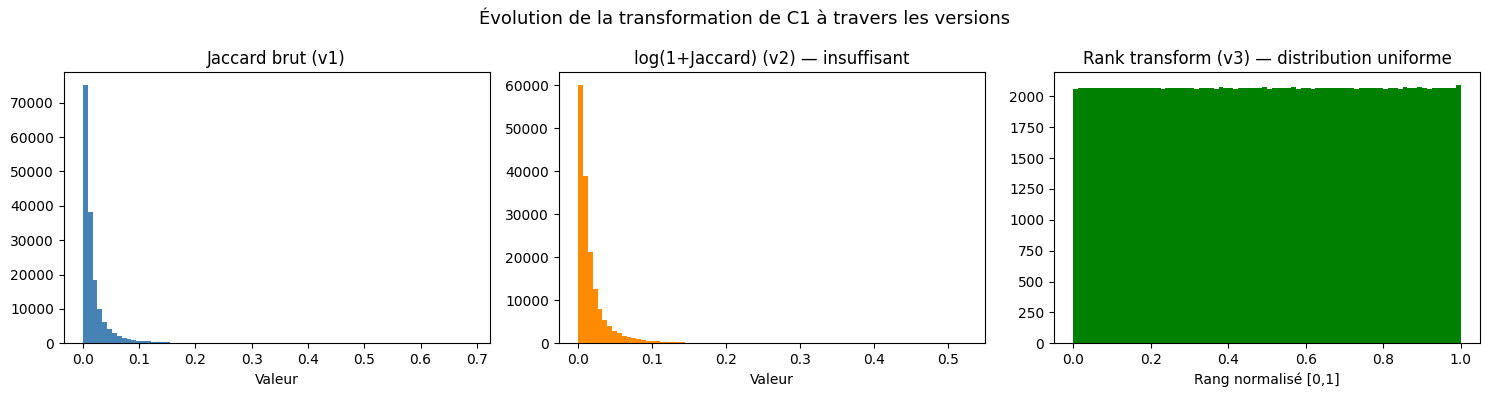

std Jaccard brut  : 0.0327
std log(1+Jacc.)  : 0.0295
std Rank transform: 0.2887  ← attendu ≈ 0.289 (uniforme)


In [4]:
# ── NOUVEAU v3 : rank transform sur C1 ──────────────────────────────────────
# La rank transform remplace chaque valeur par son rang normalisé sur [0,1].
# Elle est calculée séparément par année pour que la distribution soit
# comparable d'une période à l'autre.
#
# Pourquoi par année et non globalement ?
# Le nombre de paires actives change avec le temps (plus de brevets = plus
# de paires). Une rank transform globale avantagerait les années récentes
# qui ont plus d'observations. En rankant par année, on compare les paires
# entre elles sur la même période.

df_jaccard["C1_rank"] = (
    df_jaccard
    .groupby("year")["jaccard"]
    .rank(method="average", pct=True)  # pct=True → normalise sur [0,1]
)

# diagnostic : vérification de la distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_jaccard["jaccard"],     bins=80, color="steelblue",  edgecolor="none")
axes[0].set_title("Jaccard brut (v1)")
axes[0].set_xlabel("Valeur")

axes[1].hist(np.log1p(df_jaccard["jaccard"]), bins=80, color="darkorange", edgecolor="none")
axes[1].set_title("log(1+Jaccard) (v2) — insuffisant")
axes[1].set_xlabel("Valeur")

axes[2].hist(df_jaccard["C1_rank"],     bins=80, color="green",      edgecolor="none")
axes[2].set_title("Rank transform (v3) — distribution uniforme")
axes[2].set_xlabel("Rang normalisé [0,1]")

plt.suptitle("Évolution de la transformation de C1 à travers les versions", fontsize=13)
plt.tight_layout()
plt.savefig("comparaison_transforms_C1.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"std Jaccard brut  : {df_jaccard['jaccard'].std():.4f}")
print(f"std log(1+Jacc.)  : {np.log1p(df_jaccard['jaccard']).std():.4f}")
print(f"std Rank transform: {df_jaccard['C1_rank'].std():.4f}  ← attendu ≈ 0.289 (uniforme)")

---
## C2 — Corrélation glissante avec pondération dynamique

### Historique
- **v1** : aucun filtre → paires rares avec corrélations parasites (> 0.997)
- **v2** : filtre binaire (C2=0 si n_cooc < 50) → 85.5% des observations à 0,
  mais C2 reste volatile (0.35→0.99 en un an sur A61P×C07D en 1985)
- **v3** : **pondération dynamique** C2_effective = C2_raw × min(1, n_cooc/200)

### Justification de la pondération dynamique
Le filtre binaire de la v2 (0 ou 1) est arbitraire et crée une discontinuité :
une paire avec n_cooc=49 obtient C2=0, une paire avec n_cooc=51 obtient
sa vraie corrélation. La pondération continue est plus défendable :
- n_cooc=20  → C2 pondérée à 10% de sa valeur
- n_cooc=50  → C2 pondérée à 25%
- n_cooc=100 → C2 pondérée à 50%
- n_cooc=200 → C2 à 100% (pleinement fiable)
- n_cooc>200 → C2 inchangée (min(1, ...))

Le seuil C2_SCALING_REF=200 correspond à environ 40 brevets/an sur la fenêtre
de 5 ans, ce qui est un minimum raisonnable pour une corrélation de Pearson fiable.

Construction des séries d'activité...
Calcul de C2 (corrélation glissante, pondération dynamique)...

  → 528,334 observations
  → reliability moyenne : 0.108
  → reliability médiane : 0.000
  → paires à reliability=1 (n_cooc>=200) : 16,375 (3.1%)


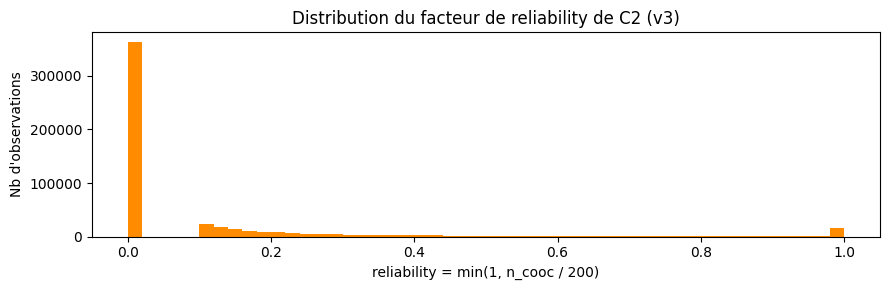

,cpc_i,cpc_j,year,rolling_corr_raw,rolling_corr,c2_reliability
0,A61P,C07D,1982,0.635334,0.635334,1.0
1,A61P,C07D,1983,0.348395,0.348395,1.0
2,A61P,C07D,1984,0.431103,0.431103,1.0
3,A61P,C07D,1985,0.986502,0.986502,1.0
4,A61P,C07D,1986,0.997572,0.997572,1.0


In [5]:
def build_activity_series(df):
    """
    Pour chaque code CPC4 et chaque année, calcule l'intensité totale
    de co-occurrence pondérée avec tous ses voisins dans le réseau.

    Pondération double :
    - 1/(m*(m-1)/2) : correction biais intra-brevet (brevets larges)
    - N_mean/N_t    : correction biais inter-annuel (volume croissant)
    """
    records = []
    for year, grp in df.groupby("year"):
        N_year   = brevet_count_by_year[year]
        w_year   = N_mean / N_year
        activity = defaultdict(float)
        for _, row in grp.iterrows():
            codes = row["cpc4"]
            m = len(codes)
            if m < 2: continue
            w_pair = (2.0 / (m * (m - 1))) * w_year
            for c in codes:
                activity[c] += w_pair * (m - 1)
        for cpc, val in activity.items():
            records.append({"cpc4": cpc, "year": year, "activity": val})
    return pd.DataFrame(records)


def compute_rolling_corr_dynamic(df_jaccard, df_activity,
                                  window=CORR_WINDOW,
                                  scaling_ref=C2_SCALING_REF):
    """
    Corrélation glissante avec pondération dynamique par n_cooc.

    NOUVEAU v3 : C2_effective = corr_raw × min(1, n_cooc / scaling_ref)
    → remplace le filtre binaire de la v2 par une transition continue
    → plus la paire est active, plus C2 est fiable et contribue à l'indice

    Retourne
    --------
    DataFrame (cpc_i, cpc_j, year, rolling_corr_raw, rolling_corr_weighted)
    """
    pivot = df_activity.pivot(
        index="year", columns="cpc4", values="activity"
    ).fillna(0)

    # lookup n_cooc : (cpc_i, cpc_j, year) → n_cooc
    cooc_lookup = (
        df_jaccard
        .set_index(["cpc_i", "cpc_j", "year"])["n_cooc"]
        .to_dict()
    )

    pairs = df_jaccard[["cpc_i", "cpc_j"]].drop_duplicates().values.tolist()
    records = []

    for ci, cj in pairs:
        if ci not in pivot.columns or cj not in pivot.columns:
            continue
        s1   = pivot[ci]
        s2   = pivot[cj]
        corr = s1.rolling(window, min_periods=3).corr(s2)

        for yr, corr_raw in corr.items():
            if np.isnan(corr_raw):
                continue
            n = cooc_lookup.get((ci, cj, yr), 0)
            # pondération dynamique : plus fiable = poids plus élevé
            reliability = min(1.0, n / scaling_ref)
            records.append({
                "cpc_i"               : ci,
                "cpc_j"               : cj,
                "year"                : yr,
                "rolling_corr_raw"    : corr_raw,
                "rolling_corr"        : corr_raw * reliability,  # C2 effective
                "c2_reliability"      : reliability,
            })

    return pd.DataFrame(records)


print("Construction des séries d'activité...")
df_activity = build_activity_series(df_raw)

print("Calcul de C2 (corrélation glissante, pondération dynamique)...")
df_corr = compute_rolling_corr_dynamic(df_jaccard, df_activity)

# diagnostic de la pondération
print(f"\n  → {len(df_corr):,} observations")
print(f"  → reliability moyenne : {df_corr['c2_reliability'].mean():.3f}")
print(f"  → reliability médiane : {df_corr['c2_reliability'].median():.3f}")
print(f"  → paires à reliability=1 (n_cooc>=200) : "
      f"{(df_corr['c2_reliability']==1).sum():,} "
      f"({100*(df_corr['c2_reliability']==1).mean():.1f}%)")

# visualisation de la distribution de reliability
fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(df_corr["c2_reliability"], bins=50, color="darkorange", edgecolor="none")
ax.set_title("Distribution du facteur de reliability de C2 (v3)")
ax.set_xlabel("reliability = min(1, n_cooc / 200)")
ax.set_ylabel("Nb d'observations")
plt.tight_layout()
plt.show()

df_corr.head()

---
## C3 — Centralité croisée (inchangée par rapport à v2)

La moyenne géométrique des strengths normalisés reste la formulation retenue.
La rank transform sera appliquée en aval lors de la normalisation finale,
ce qui élimine le besoin d'une transformation supplémentaire ici.

In [6]:
centrality_df = pd.read_csv("centrality_results.csv")

if "t_center" not in centrality_df.columns:
    centrality_df["t_center"] = (
        centrality_df["window_start"] + centrality_df["window_end"]
    ) / 2.0
centrality_df["year"] = centrality_df["t_center"].round().astype(int)

# normalisation min-max du strength par année
# (la rank transform globale sera appliquée plus tard)
scaler = MinMaxScaler()
centrality_df["strength_norm"] = (
    centrality_df
    .groupby("year")["strength"]
    .transform(lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten())
)
strength_lookup = (
    centrality_df
    .set_index(["cpc4", "year"])["strength_norm"]
    .to_dict()
)


def compute_cross_centrality(df_jaccard, strength_lookup):
    """
    Moyenne géométrique des strengths normalisés des deux codes.

    Formule : C3(i,j,t) = sqrt(strength_norm(i,t) × strength_norm(j,t))

    Justification de la moyenne géométrique vs arithmétique :
    La moyenne géométrique pénalise fortement les paires asymétriques
    où l'un des codes est très périphérique. Si s_i=1 et s_j=0.01,
    moy. arithmétique = 0.505 (trompeuse), moy. géométrique = 0.10.
    """
    df = df_jaccard[["cpc_i", "cpc_j", "year"]].copy()
    df["s_i"] = df.apply(
        lambda r: strength_lookup.get((r["cpc_i"], r["year"]), np.nan), axis=1
    )
    df["s_j"] = df.apply(
        lambda r: strength_lookup.get((r["cpc_j"], r["year"]), np.nan), axis=1
    )
    df["cross_centrality"] = np.sqrt(df["s_i"] * df["s_j"])
    return df[["cpc_i", "cpc_j", "year", "cross_centrality"]]


print("Calcul de C3 (centralité croisée)...")
df_centrality_cross = compute_cross_centrality(df_jaccard, strength_lookup)
n_valid = df_centrality_cross["cross_centrality"].notna().sum()
print(f"  → {n_valid:,} valeurs non-NaN ({100*n_valid/len(df_centrality_cross):.1f}%)")

Calcul de C3 (centralité croisée)...
  → 153,950 valeurs non-NaN (93.0%)


---
## C4 — Cluster absorbant (inchangée par rapport à v2)

Le score d'absorption = entropie des entrées × persistance reste la formulation
retenue. Le filtre taxonomique s'applique en amont (via df_jaccard),
donc C10M×C10N sera automatiquement exclu du panel final.

In [7]:
def build_cooc_matrix(df, year_start, year_end):
    """Matrice de co-occurrence normalisée pour une fenêtre temporelle."""
    df_w = df[(df["year"] >= year_start) & (df["year"] <= year_end)]
    df_w = df_w[df_w["cpc4"].apply(lambda x: len(x) >= 2)]
    pair_counter = Counter()
    for cpcs in df_w["cpc4"]:
        for ci, cj in itertools.combinations(sorted(set(cpcs)), 2):
            pair_counter[(ci, cj)] += 1
            pair_counter[(cj, ci)] += 1
    cooc = pd.DataFrame(
        [(i, j, c) for (i, j), c in pair_counter.items()],
        columns=["cpc_i", "cpc_j", "count"]
    )
    row_sums = cooc.groupby("cpc_i")["count"].sum().rename("row_sum")
    cooc = cooc.join(row_sums, on="cpc_i")
    cooc["M_ij"] = cooc["count"] / cooc["row_sum"]
    return cooc


print("Clustering dynamique (fenêtres annuelles)...")
pca_clust  = PCA(n_components=N_PCA_CLUST, random_state=0)
kmeans_obj = KMeans(n_clusters=K_CLUSTERS, random_state=0, n_init=10)

cluster_time = []
for start in range(YEAR_START, YEAR_END - WINDOW + 2):
    end = start + WINDOW - 1
    cooc_w = build_cooc_matrix(df_raw, start, end)
    if len(cooc_w) == 0: continue
    M_w = cooc_w.pivot(index="cpc_i", columns="cpc_j", values="M_ij").fillna(0)
    if M_w.shape[0] < N_PCA_CLUST: continue
    M_pca_w  = pca_clust.fit_transform(M_w)
    clusters = kmeans_obj.fit_predict(M_pca_w)
    cluster_time.append(
        pd.DataFrame({"cpc": M_w.index, "cluster": clusters,
                      "year": start + WINDOW // 2})
    )

cluster_time_df = pd.concat(cluster_time, ignore_index=True)
print(f"  → {cluster_time_df['year'].nunique()} années")

Clustering dynamique (fenêtres annuelles)...
  → 39 années


In [8]:
def entropy_fn(p):
    p = p[p > 0]
    return -np.sum(p * np.log(p))

# transitions inter-clusters
df_cl = cluster_time_df.sort_values(["cpc", "year"]).copy()
transitions = []
for cpc, sub in df_cl.groupby("cpc"):
    sub = sub.sort_values("year")
    for i in range(len(sub) - 1):
        transitions.append({
            "cpc"        : cpc,
            "year_t"     : sub.iloc[i]["year"],
            "year_t1"    : sub.iloc[i+1]["year"],
            "cluster_t"  : sub.iloc[i]["cluster"],
            "cluster_t1" : sub.iloc[i+1]["cluster"],
        })
trans_df = pd.DataFrame(transitions)

# entropie des entrées
inflow = (
    trans_df
    .groupby(["year_t1", "cluster_t1"])["cluster_t"]
    .value_counts(normalize=True).rename("p").reset_index()
)
inflow_H = (
    inflow.groupby(["year_t1", "cluster_t1"])["p"]
    .apply(entropy_fn).reset_index(name="H_in")
)

# persistance
persist = (
    trans_df
    .groupby(["year_t", "cluster_t"])
    .apply(lambda x: np.mean(x["cluster_t1"] == x["cluster_t"]))
    .reset_index(name="persistence")
)

absorption_df = inflow_H.merge(
    persist,
    left_on=["year_t1", "cluster_t1"],
    right_on=["year_t",  "cluster_t"],
    how="left"
).drop(columns=["year_t", "cluster_t"])
absorption_df = absorption_df.rename(
    columns={"year_t1": "year", "cluster_t1": "cluster"}
)
absorption_df["absorption_score"] = (
    absorption_df["H_in"] * absorption_df["persistence"].fillna(0)
)

# seuil absorbant : double critère au 75e percentile
H_thresh = absorption_df["H_in"].quantile(0.75)
P_thresh = absorption_df["persistence"].quantile(0.75)
absorption_df["is_absorbing"] = (
    (absorption_df["H_in"] >= H_thresh) &
    (absorption_df["persistence"] >= P_thresh)
)
print(f"Clusters absorbants : {absorption_df['is_absorbing'].sum()} / {len(absorption_df)}")


def compute_cluster_component(df_jaccard, cluster_time_df, absorption_df):
    """
    Pour chaque paire (i,j,t), retourne le score d'absorption du cluster
    si les deux codes y sont co-localisés dans un cluster absorbant, sinon 0.
    """
    cluster_lookup = cluster_time_df.set_index(["cpc", "year"])["cluster"].to_dict()
    absorb_lookup  = absorption_df.set_index(["year", "cluster"])["absorption_score"].to_dict()

    df = df_jaccard[["cpc_i", "cpc_j", "year"]].copy()

    def row_c4(r):
        cl_i = cluster_lookup.get((r["cpc_i"], r["year"]))
        cl_j = cluster_lookup.get((r["cpc_j"], r["year"]))
        if cl_i is None or cl_j is None or cl_i != cl_j:
            return 0.0
        return absorb_lookup.get((r["year"], cl_i), 0.0)

    df["cluster_absorption"] = df.apply(row_c4, axis=1)
    return df[["cpc_i", "cpc_j", "year", "cluster_absorption"]]


print("Calcul de C4...")
df_cluster_c4 = compute_cluster_component(df_jaccard, cluster_time_df, absorption_df)
n_abs = (df_cluster_c4["cluster_absorption"] > 0).sum()
print(f"  → {n_abs:,} paires dans un cluster absorbant "
      f"({100*n_abs/len(df_cluster_c4):.1f}%)")

Clusters absorbants : 37 / 379
Calcul de C4...
  → 24,480 paires dans un cluster absorbant (14.8%)


---
## Assemblage du panel et normalisation par rank transform

### Normalisation v3 : rank transform sur toutes les composantes

La rank transform est appliquée **par année** sur les 4 composantes.

**Pourquoi abandonner le min-max pour toutes les composantes ?**
- En v2, std(C1)=0.06, std(C2)=0.35 après min-max → C2 domine quelle que soit
  la pondération linéaire choisie
- La rank transform garantit std ≈ 0.289 pour toutes les composantes (distribution
  uniforme sur [0,1]), rendant les poids directement interprétables

**Exception pour C2** : C2 intègre déjà la pondération dynamique par reliability.
La rank transform s'applique sur C2_raw (corr × reliability), ce qui préserve
le signal de fiabilité dans le rang.

In [9]:
keys = ["cpc_i", "cpc_j", "year"]

panel = (
    df_jaccard[["cpc_i", "cpc_j", "year", "jaccard", "C1_rank",
                "p_j_given_i", "p_i_given_j", "n_cooc"]]
    .merge(
        df_corr[["cpc_i", "cpc_j", "year",
                 "rolling_corr", "rolling_corr_raw", "c2_reliability"]],
        on=keys, how="left"
    )
    .merge(df_centrality_cross, on=keys, how="left")
    .merge(df_cluster_c4,       on=keys, how="left")
)

panel["rolling_corr"]       = panel["rolling_corr"].fillna(0)
panel["rolling_corr_raw"]   = panel["rolling_corr_raw"].fillna(0)
panel["c2_reliability"]     = panel["c2_reliability"].fillna(0)
panel["cross_centrality"]   = panel["cross_centrality"].fillna(0)
panel["cluster_absorption"] = panel["cluster_absorption"].fillna(0)

# troncature à YEAR_END
panel = panel[panel["year"] <= YEAR_END].copy()

print(f"Panel : {len(panel):,} lignes, {panel['year'].nunique()} années")
print(f"Codes uniques : {pd.concat([panel['cpc_i'], panel['cpc_j']]).nunique()}")

Panel : 145,843 lignes, 43 années
Codes uniques : 598


In [10]:
# ── Rank transform par année sur les 4 composantes ───────────────────────────
def rank_by_year(df, col):
    """
    Rank transform par année : remplace chaque valeur par son rang
    normalisé sur [0,1] au sein de la même année.
    Les ex-aequo reçoivent le rang moyen (method='average').
    """
    return (
        df.groupby("year")[col]
        .rank(method="average", pct=True)
    )

# C1 : rank transform du Jaccard (déjà calculé mais on le recalcule sur le panel final)
panel["C1_jaccard"] = rank_by_year(panel, "jaccard")

# C2 : rank transform de la corrélation pondérée (rolling_corr = corr × reliability)
panel["C2_corr"] = rank_by_year(panel, "rolling_corr")

# C3 : rank transform de la centralité croisée
panel["C3_centrality"] = rank_by_year(panel, "cross_centrality")

# C4 : rank transform du score d'absorption
panel["C4_cluster"] = rank_by_year(panel, "cluster_absorption")

norm_cols = ["C1_jaccard", "C2_corr", "C3_centrality", "C4_cluster"]

print("Stats des composantes après rank transform :")
print(panel[norm_cols].describe().round(4))
print("\n→ Toutes les std doivent être ≈ 0.289 (distribution uniforme)")
print("→ Toutes les moyennes doivent être ≈ 0.5")

Stats des composantes après rank transform :
        C1_jaccard      C2_corr  C3_centrality   C4_cluster
count  145843.0000  145843.0000    145843.0000  145843.0000
mean        0.5001       0.5001         0.5001       0.5001
std         0.2887       0.2885         0.2885       0.1759
min         0.0001       0.0001         0.0001       0.2355
25%         0.2501       0.2505         0.2505       0.4014
50%         0.5001       0.5008         0.5008       0.4498
75%         0.7502       0.7498         0.7498       0.5001
max         1.0000       1.0000         1.0000       0.9999

→ Toutes les std doivent être ≈ 0.289 (distribution uniforme)
→ Toutes les moyennes doivent être ≈ 0.5


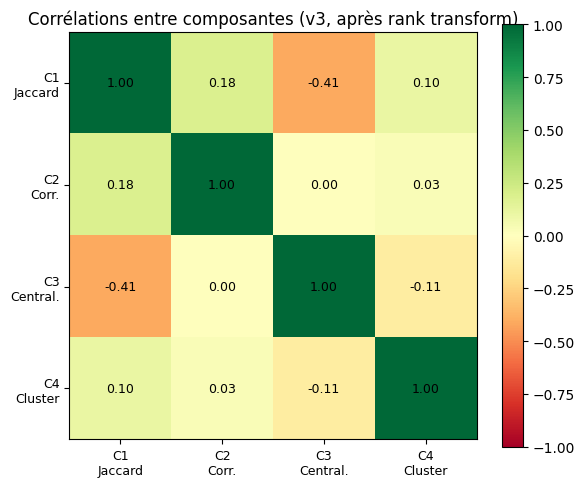


→ Comparer avec v1 (toutes < 0.10) et v2 (C1×C2=0.32)


In [11]:
# ── Matrice de corrélation post-rank transform ────────────────────────────────
corr_matrix = panel[norm_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(4))
ax.set_yticks(range(4))
labels = ["C1\nJaccard", "C2\nCorr.", "C3\nCentral.", "C4\nCluster"]
ax.set_xticklabels(labels, fontsize=9)
ax.set_yticklabels(labels, fontsize=9)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{corr_matrix.iloc[i,j]:.2f}",
                ha="center", va="center", fontsize=9)
ax.set_title("Corrélations entre composantes (v3, après rank transform)")
plt.tight_layout()
plt.savefig("correlation_composantes_v3.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n→ Comparer avec v1 (toutes < 0.10) et v2 (C1×C2=0.32)")

---
## Agrégation v3 : pondération explicite sur rank-transformées

Les poids sont appliqués sur des composantes de variance identique.
Ils sont maintenant directement interprétables comme des contributions
relatives à l'indice final.

In [12]:
# ── Indice principal v3 ──────────────────────────────────────────────────────
panel["CI_v3"] = sum(W[col] * panel[col] for col in norm_cols)

# normalisation finale [0,1]
panel["CI_v3"] = (
    (panel["CI_v3"] - panel["CI_v3"].min()) /
    (panel["CI_v3"].max() - panel["CI_v3"].min())
)

# ── Variantes de robustesse ──────────────────────────────────────────────────
# Variante A : C1 seul (baseline de référence)
panel["CI_C1_only"] = panel["C1_jaccard"]

# Variante B : poids égaux (test de sensibilité)
ci_eq = panel[norm_cols].mean(axis=1)
panel["CI_equal"] = (ci_eq - ci_eq.min()) / (ci_eq.max() - ci_eq.min())

# Variante C : sans C2 (mesure de l'apport de la corrélation)
w_no_c2 = {"C1_jaccard": 0.55, "C3_centrality": 0.25, "C4_cluster": 0.20}
ci_nc2 = sum(w * panel[col] for col, w in w_no_c2.items())
panel["CI_no_c2"] = (ci_nc2 - ci_nc2.min()) / (ci_nc2.max() - ci_nc2.min())

print(f"CI_v3 : mean={panel['CI_v3'].mean():.4f}, std={panel['CI_v3'].std():.4f}")
print("\nCorrélations entre variantes :")
display(panel[["CI_v3", "CI_C1_only", "CI_equal", "CI_no_c2"]].corr().round(3))

print("\n→ En v2 : CI_v2/CI_equal=0.988 (indiscernables)")
print("→ En v3 : on attend des corrélations plus modérées")
print("  grâce à la rank transform qui équilibre les variances")

CI_v3 : mean=0.4211, std=0.1701

Corrélations entre variantes :


,CI_v3,CI_C1_only,CI_equal,CI_no_c2
CI_v3,1.000,0.819,0.898,0.922
CI_C1_only,0.819,1.000,0.488,0.879
CI_equal,0.898,0.488,1.000,0.743
CI_no_c2,0.922,0.879,0.743,1.000



→ En v2 : CI_v2/CI_equal=0.988 (indiscernables)
→ En v3 : on attend des corrélations plus modérées
  grâce à la rank transform qui équilibre les variances


---
## Validation sur les cas connus (ground truth)

Critères de succès :
1. **C12N × A61K** : CI faible avant 1995, hausse nette après → biotech/biopharma
2. **H01M × B60L** : CI quasi nul avant 2005, hausse nette après 2010 → véhicule électrique
3. Les deux paires doivent survivre au filtre taxonomique
   (C12N et A61K ont des préfixes différents ✓, H01M et B60L aussi ✓)

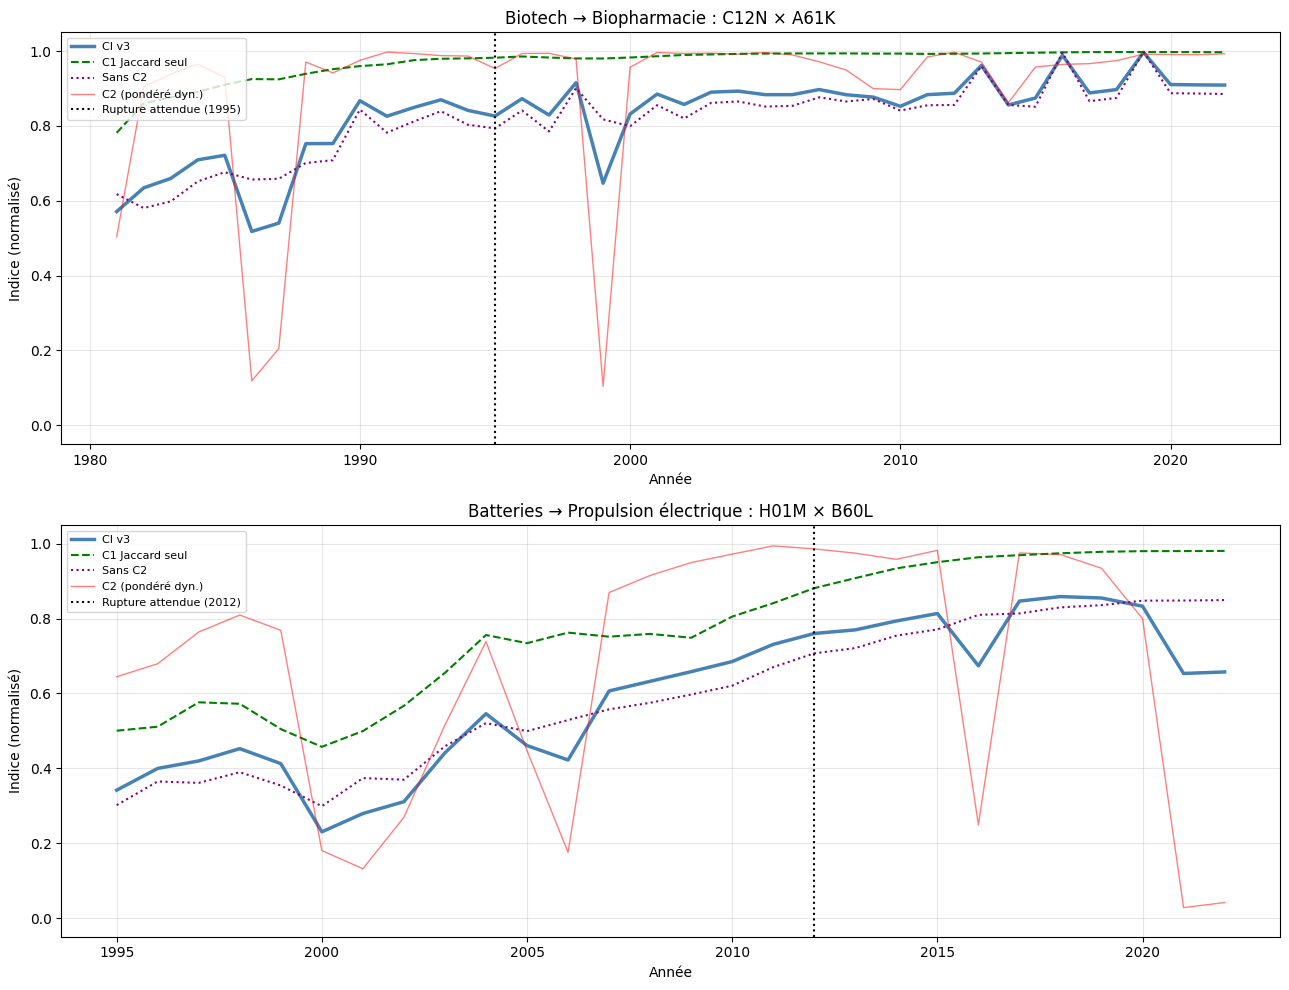

In [13]:
def plot_pair_validation(panel, ci, cj, label, expected_break, ax=None):
    mask = (
        ((panel["cpc_i"] == ci) & (panel["cpc_j"] == cj)) |
        ((panel["cpc_i"] == cj) & (panel["cpc_j"] == ci))
    )
    sub = panel[mask].sort_values("year")

    if len(sub) == 0:
        print(f"⚠ Paire {ci}×{cj} absente du panel")
        return

    if ax is None:
        fig, ax = plt.subplots(figsize=(11, 4))

    ax.plot(sub["year"], sub["CI_v3"],      lw=2.5, color="steelblue",  label="CI v3")
    ax.plot(sub["year"], sub["CI_C1_only"], lw=1.5, color="green",  ls="--", label="C1 Jaccard seul")
    ax.plot(sub["year"], sub["CI_no_c2"],   lw=1.5, color="purple", ls=":",  label="Sans C2")
    ax.plot(sub["year"], sub["C2_corr"],    lw=1.0, color="red",   alpha=0.5, label="C2 (pondéré dyn.)")
    ax.axvline(expected_break, color="black", ls=":", lw=1.5,
               label=f"Rupture attendue ({expected_break})")
    ax.set_title(f"{label} : {ci} × {cj}")
    ax.set_xlabel("Année")
    ax.set_ylabel("Indice (normalisé)")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    return ax


fig, axes = plt.subplots(2, 1, figsize=(13, 10))
plot_pair_validation(panel, "C12N", "A61K",
                     "Biotech → Biopharmacie", expected_break=1995, ax=axes[0])
plot_pair_validation(panel, "H01M", "B60L",
                     "Batteries → Propulsion électrique", expected_break=2012, ax=axes[1])
plt.tight_layout()
plt.savefig("validation_v3.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Top convergences par année

In [14]:
def top_convergences(panel, year, n=10):
    """
    Top n paires les plus convergentes à une année donnée.
    Affiche aussi n_cooc et c2_reliability pour diagnostic.
    """
    return (
        panel[panel["year"] == year]
        .nlargest(n, "CI_v3")[
            ["cpc_i", "cpc_j", "CI_v3",
             "C1_jaccard", "C2_corr", "C3_centrality", "C4_cluster",
             "jaccard", "n_cooc", "c2_reliability"]
        ]
        .reset_index(drop=True)
    )

# test de sanité : les paires taxonomiques ne doivent plus apparaître
# (ex. C10M×C10N, A61K×A61P, E05D×E05Y...)
for yr in [1990, 2000, 2010, 2020]:
    print(f"\n── Top 10 convergences en {yr} ──────────────────────────")
    top = top_convergences(panel, yr, n=10)
    # vérification automatique : aucune paire ne doit partager le même préfixe
    same_prefix = (
        top["cpc_i"].str[:3] == top["cpc_j"].str[:3]
    ).any()
    if same_prefix:
        print("⚠ ATTENTION : des paires taxonomiques sont encore présentes !")
    display(top)


── Top 10 convergences en 1990 ──────────────────────────


,cpc_i,cpc_j,CI_v3,C1_jaccard,C2_corr,C3_centrality,C4_cluster,jaccard,n_cooc,c2_reliability
0,A61P,C07D,0.953736,0.998391,0.997586,0.982301,0.745374,0.395224,1986,1.0
1,A01N,C07D,0.928370,0.978278,0.990346,0.925986,0.745374,0.172519,737,1.0
2,A61P,C07C,0.913084,0.947707,0.958970,0.960579,0.745374,0.101866,546,1.0
3,B01J,Y02P,0.904551,0.914722,0.976669,0.876106,0.884553,0.075347,309,1.0
4,A61K,C07K,0.892641,0.989541,0.987932,0.749799,0.745374,0.249914,723,1.0
5,A01N,C07C,0.887343,0.927595,0.989541,0.864843,0.745374,0.085953,309,1.0
6,F02B,Y02T,0.887156,0.995977,0.995173,0.600161,0.884553,0.295063,514,1.0
7,A61P,C07K,0.885937,0.951730,0.943685,0.850362,0.745374,0.108844,448,1.0
8,B01J,C01B,0.885608,0.950121,0.993564,0.698311,0.884553,0.107243,305,1.0
9,B01J,C10G,0.884858,0.969429,0.996782,0.648431,0.884553,0.131986,333,1.0



── Top 10 convergences en 2000 ──────────────────────────


,cpc_i,cpc_j,CI_v3,C1_jaccard,C2_corr,C3_centrality,C4_cluster,jaccard,n_cooc,c2_reliability
0,G06F,H04N,0.920153,0.887285,0.996740,0.918025,0.973451,0.056243,282,1.0
1,G06T,H04N,0.919909,0.979972,0.979041,0.726129,0.973451,0.137865,430,1.0
2,G06F,H04L,0.918253,0.966465,0.993479,0.734979,0.973451,0.108661,340,1.0
3,C08L,C09D,0.908033,0.972986,0.972054,0.775966,0.869353,0.121266,479,1.0
4,G11B,H04N,0.898627,0.981835,0.711691,0.897997,0.973451,0.144934,618,1.0
5,G06F,G11B,0.890131,0.869585,0.948300,0.877503,0.973451,0.051270,222,1.0
6,B01J,Y02P,0.882109,0.925477,0.973451,0.908244,0.685375,0.071995,427,1.0
7,C08L,C09J,0.873477,0.985561,0.987424,0.584071,0.869353,0.156510,452,1.0
8,A61P,C07D,0.872934,0.998137,0.990685,0.985095,0.289474,0.360841,2816,1.0
9,B29C,C08J,0.869025,0.918491,0.952026,0.751281,0.869353,0.067529,308,1.0



── Top 10 convergences en 2010 ──────────────────────────


,cpc_i,cpc_j,CI_v3,C1_jaccard,C2_corr,C3_centrality,C4_cluster,jaccard,n_cooc,c2_reliability
0,H01L,H05K,0.941042,0.980743,0.988066,0.897478,0.851505,0.116025,753,1.0
1,B29C,Y10T,0.934087,0.923244,0.989151,0.995932,0.851505,0.057298,1617,1.0
2,C08L,Y10T,0.925503,0.911581,0.980743,0.993762,0.851505,0.053000,1485,1.0
3,C08G,C09D,0.922863,0.991050,0.964741,0.819637,0.851505,0.175693,983,1.0
4,C08L,C09D,0.921061,0.988337,0.938161,0.844589,0.851505,0.153298,1011,1.0
5,C08F,C09D,0.900986,0.972606,0.951993,0.780038,0.851505,0.100075,536,1.0
6,F02D,Y02T,0.900646,0.995932,0.967724,0.871983,0.636018,0.225432,1592,1.0
7,F01N,Y02T,0.900093,0.994033,0.991050,0.850556,0.636018,0.195790,1386,1.0
8,G06T,H04N,0.897279,0.986981,0.995118,0.820993,0.675075,0.144699,707,1.0
9,H01L,H10D,0.896639,0.988066,0.924871,0.753729,0.851505,0.152961,744,1.0



── Top 10 convergences en 2020 ──────────────────────────


,cpc_i,cpc_j,CI_v3,C1_jaccard,C2_corr,C3_centrality,C4_cluster,jaccard,n_cooc,c2_reliability
0,G06F,H04L,0.915906,0.999411,0.999411,0.999902,0.500049,0.301839,12341,1.0
1,A61P,C07D,0.913726,0.999313,0.998233,0.991950,0.500049,0.298666,7524,1.0
2,A61K,C07D,0.911695,0.997840,0.991459,0.993324,0.500049,0.215465,6289,1.0
3,A61K,C07K,0.911598,0.998920,0.991655,0.990281,0.500049,0.278762,7584,1.0
4,A61P,C07K,0.910962,0.999018,0.990968,0.988023,0.500049,0.279216,6991,1.0
5,A61K,C12N,0.910453,0.997349,0.990772,0.989790,0.500049,0.202614,5907,1.0
6,G06F,H04W,0.910053,0.990477,0.995288,0.999018,0.500049,0.113776,4653,1.0
7,G06F,H04N,0.909046,0.986943,0.998626,0.999313,0.500049,0.100232,4190,1.0
8,A61P,C12N,0.908920,0.996957,0.987532,0.987336,0.500049,0.192322,5210,1.0
9,H01M,Y02E,0.908330,0.999804,0.971039,0.994895,0.500049,0.411395,11315,1.0


---
## Évolution temporelle de l'indice (v3)

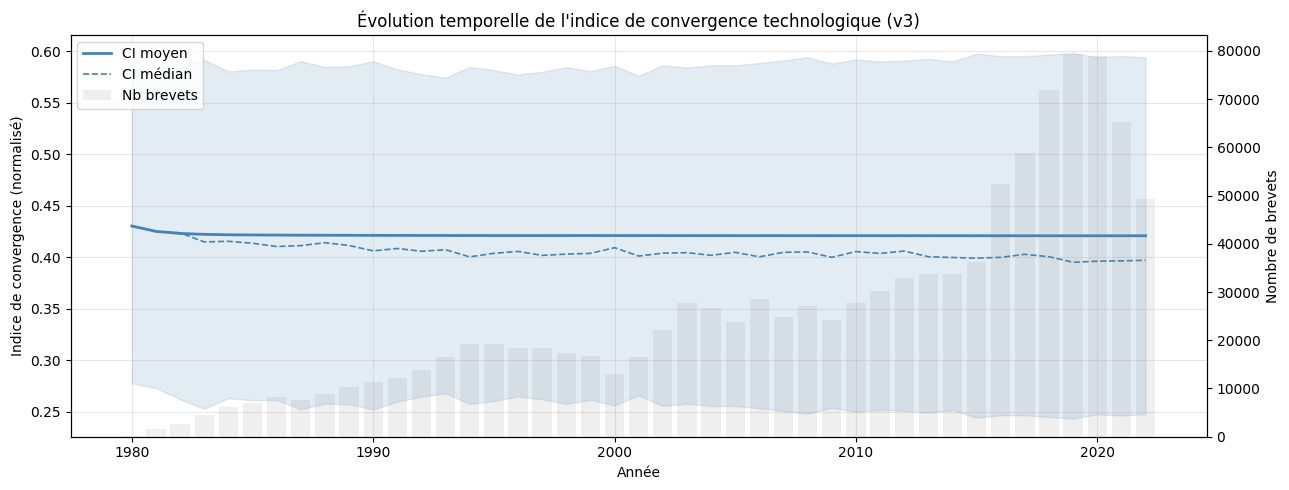


→ On attend maintenant une tendance globalement croissante
  (espace technologique de plus en plus interconnecté)
  avec accélérations autour de 1990-1995 (biotech) et 2010-2015 (IA)


In [15]:
yearly_patents = pd.Series(brevet_count_by_year).rename("n_patents")

CI_time = (
    panel.groupby("year")["CI_v3"]
    .agg(["mean", "median", "std"])
    .join(yearly_patents)
)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.fill_between(
    CI_time.index,
    (CI_time["mean"] - CI_time["std"]).clip(0),
    (CI_time["mean"] + CI_time["std"]).clip(upper=1),
    alpha=0.15, color="steelblue"
)
ax1.plot(CI_time.index, CI_time["mean"],   color="steelblue", lw=2,   label="CI moyen")
ax1.plot(CI_time.index, CI_time["median"], color="steelblue", lw=1.2, ls="--", label="CI médian")
ax2.bar(CI_time.index, CI_time["n_patents"], alpha=0.12, color="gray", label="Nb brevets")

ax1.set_xlabel("Année")
ax1.set_ylabel("Indice de convergence (normalisé)")
ax2.set_ylabel("Nombre de brevets")
ax1.set_title("Évolution temporelle de l'indice de convergence technologique (v3)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("CI_temporal_v3.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n→ On attend maintenant une tendance globalement croissante")
print("  (espace technologique de plus en plus interconnecté)")
print("  avec accélérations autour de 1990-1995 (biotech) et 2010-2015 (IA)")

---
## Export final

In [ ]:
cols_export = [
    "cpc_i", "cpc_j", "year",
    "C1_jaccard", "C2_corr", "C3_centrality", "C4_cluster",
    "CI_v3", "CI_C1_only", "CI_equal", "CI_no_c2",
    "jaccard", "p_j_given_i", "p_i_given_j",
    "rolling_corr", "rolling_corr_raw", "c2_reliability", "n_cooc"
]
panel[cols_export].to_parquet("indice_convergence_v3.parquet", index=False)
panel[cols_export].to_csv("indice_convergence_v3.csv", index=False)

print("Fichiers exportés : indice_convergence_v3.parquet / .csv")
print(f"  → {len(panel):,} lignes | {panel['year'].nunique()} années "
      f"| {pd.concat([panel['cpc_i'], panel['cpc_j']]).nunique()} codes")
panel[cols_export].describe().round(4)